In [1]:
import sys
import os

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

# Evaluando los modelos construidos

En este notebook se evalúan y comparan dos modelos supervisados previamente entrenados para la predicción de depresión estudiantil:

- Regresión Logística
- Random Forest

La evaluación considera múltiples métricas de rendimiento y validación cruzada, con el objetivo de analizar la capacidad de generalización de los modelos y comparar su desempeño en un contexto relacionado con salud mental.

Como los casos de depresión son un asunto muy sensible, se enfatizará especialmente en métricas como Recall y F1-score, debido a la importancia de identificar correctamente posibles casos de depresión y reducir falsos negativos.

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from src.carga import cargar_csv

Primeramente se cargarán tanto los datos como los modelos supervisados construidos anteriormente en la fase 2 

In [4]:
#Dataset
df = cargar_csv("../data/processed/Student_Depression_Dataset_codificado.csv")

#Variables predictoras y variable objetivo
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

#División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Modelos
try:
    model_rl = joblib.load("../outputs/models/logistic_regression_model.pkl")
    model_rf = joblib.load("../outputs/models/random_forest_model.pkl")
except:
    print("Error, modelos no fueron cargados")
else:
    print("Modelos cargados correctamente.")

Modelos cargados correctamente.


#### Evaluación Inicial

Se generan predicciones utilizando ambos modelos sobre el conjunto de prueba.

Posteriormente, se calculan métricas fundamentales de clasificación para evaluar el desempeño inicial de cada modelo:

- Accuracy
- Precision
- Recall
- F1-score


In [5]:
y_pred_rl = model_rl.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [10]:
metrics_rl = {
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_score(y_test, y_pred_rl),
    "Precision": precision_score(y_test, y_pred_rl),
    "Recall": recall_score(y_test, y_pred_rl),
    "F1-Score": f1_score(y_test, y_pred_rl)
}

print("=== REGRESIÓN LOGÍSTICA ===\n")

for metric, value in metrics_rl.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
report_dict = classification_report(y_test, y_pred_rl, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

=== REGRESIÓN LOGÍSTICA ===

Accuracy: 0.8499
Precision: 0.8588
Recall: 0.8902
F1-Score: 0.8742

=== REPORTE DE CLASIFICACIÓN ===


,precision,recall,f1-score,support
0.0,0.836231,0.793059,0.814073,2305.000000
1.0,0.858792,0.890150,0.874190,3259.000000
accuracy,0.849928,0.849928,0.849928,0.849928
macro avg,0.847511,0.841604,0.844131,5564.000000
weighted avg,0.849446,0.849928,0.849285,5564.000000


In [11]:
metrics_rf = {
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

print("\n\n=== RANDOM FOREST ===\n")

for metric, value in metrics_rf.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report



=== RANDOM FOREST ===

Accuracy: 0.8490
Precision: 0.8536
Recall: 0.8960
F1-Score: 0.8743

=== REPORTE DE CLASIFICACIÓN ===


,precision,recall,f1-score,support
0.0,0.841811,0.782646,0.811151,2305.000000
1.0,0.853552,0.895980,0.874251,3259.000000
accuracy,0.849029,0.849029,0.849029,0.849029
macro avg,0.847681,0.839313,0.842701,5564.000000
weighted avg,0.848688,0.849029,0.848111,5564.000000


Comparamos ambos modelos

In [13]:
comparison_df = pd.DataFrame([
    metrics_rl,
    metrics_rf
])

print("\n=== COMPARACIÓN DE MODELOS ===\n")
comparison_df


=== COMPARACIÓN DE MODELOS ===



,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.849928,0.858792,0.89015,0.874190
1,Random Forest,0.849029,0.853552,0.89598,0.874251


#### Validación Cruzada

Ahora, para una evaluación más robusta y reducir dependencia de una única división entrenamiento/prueba, aplicaremos una validación cruzada sobre ambos modelos.

Utilizando las mismas métricas de evaluación:

- Accuracy
- Precision
- Recall
- F1-score

Además de los valores promedio, se calcula la desviación estándar para analizar estabilidad y consistencia de los modelos.

$$CV = \frac{1}{k} \sum_{i=1}^{k} \text{Score}_i$$

In [14]:
# CONFIGURACIÓN MÉTRICAS CV
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# VALIDACIÓN CRUZADA RL
cv_rl = cross_validate(
    model_rl,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# VALIDACIÓN CRUZADA RF
cv_rf = cross_validate(
    model_rf,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

cv_results_rl = {
    "Modelo": "Regresión Logística",
    
    "Accuracy Mean": cv_rl["test_accuracy"].mean(),
    "Accuracy Std": cv_rl["test_accuracy"].std(),
    
    "Precision Mean": cv_rl["test_precision"].mean(),
    "Precision Std": cv_rl["test_precision"].std(),
    
    "Recall Mean": cv_rl["test_recall"].mean(),
    "Recall Std": cv_rl["test_recall"].std(),
    
    "F1 Mean": cv_rl["test_f1"].mean(),
    "F1 Std": cv_rl["test_f1"].std()
}

cv_results_rf = {
    "Modelo": "Random Forest",
    
    "Accuracy Mean": cv_rf["test_accuracy"].mean(),
    "Accuracy Std": cv_rf["test_accuracy"].std(),
    
    "Precision Mean": cv_rf["test_precision"].mean(),
    "Precision Std": cv_rf["test_precision"].std(),
    
    "Recall Mean": cv_rf["test_recall"].mean(),
    "Recall Std": cv_rf["test_recall"].std(),
    
    "F1 Mean": cv_rf["test_f1"].mean(),
    "F1 Std": cv_rf["test_f1"].std()
}

In [15]:
#Tabla comparativa de validación cruzada
cv_comparison_df = pd.DataFrame([
    cv_results_rl,
    cv_results_rf
])

print("=== VALIDACIÓN CRUZADA ===\n")
cv_comparison_df

=== VALIDACIÓN CRUZADA ===



,Modelo,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,Regresión Logística,0.847467,0.004219,0.858014,0.006548,0.886338,0.001625,0.871930,0.003007
1,Random Forest,0.842830,0.002417,0.851869,0.003650,0.885725,0.003302,0.868457,0.001881


#### Matrices de Confusión

Las matrices de confusión permiten visualizar de manera detallada el comportamiento de los modelos respecto a las clasificaciones correctas e incorrectas.

En este caso, los falsos negativos van a ser especialmente relevantes, ya que representan estudiantes con posible depresión clasificados incorrectamente como "No tiene depresión".

Por esta razón, además del accuracy, resulta fundamental analizar métricas como Recall y F1-score.

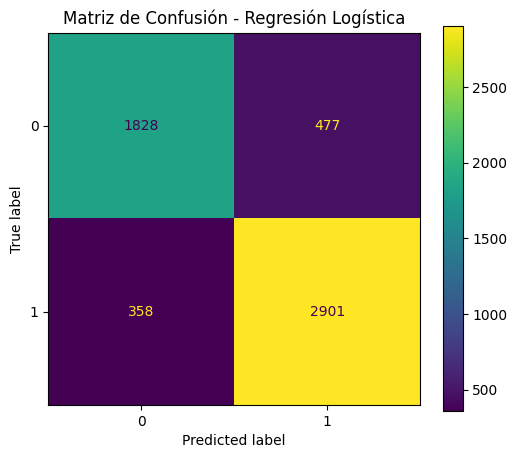

In [16]:
cm_rl = confusion_matrix(y_test, y_pred_rl)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rl = ConfusionMatrixDisplay(confusion_matrix=cm_rl)
disp_rl.plot(ax=ax)
plt.title("Matriz de Confusión - Regresión Logística")
plt.savefig("../outputs/plots/confusion_matrix_rl.png", bbox_inches="tight")
plt.show()

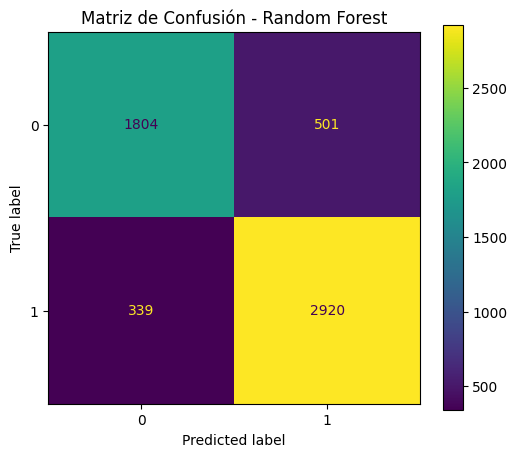

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=ax)
plt.title("Matriz de Confusión - Random Forest")
plt.savefig("../outputs/plots/confusion_matrix_rf.png", bbox_inches="tight")
plt.show()

#### Otros gráficos
A modo de facilitar la comparación entre modelos, se visualizan las principales métricas de clasificación obtenidas sobre el conjunto de prueba (xtest).


### **Gráfico de barras de las métricas calculadas para ambos modelos**

                     Accuracy  Precision   Recall  F1-Score
Modelo                                                     
Regresión Logística  0.849928   0.858792  0.89015  0.874190
Random Forest        0.849029   0.853552  0.89598  0.874251


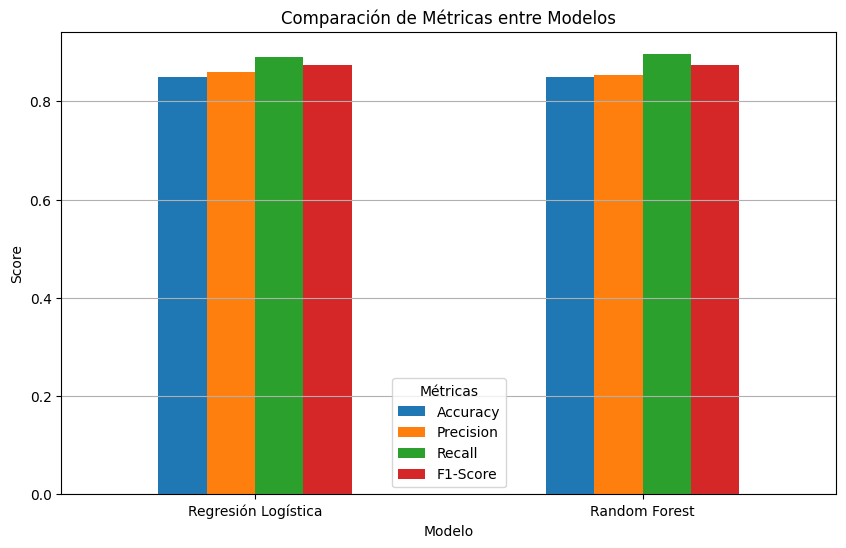

In [18]:
metrics_plot_df = comparison_df.set_index("Modelo")
print(metrics_plot_df)
fig, ax = plt.subplots(figsize=(10, 6))
metrics_plot_df.plot(kind="bar", ax=ax)
plt.title("Comparación de Métricas entre Modelos")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.legend(title="Métricas")
plt.grid(axis="y")
plt.savefig("../outputs/plots/metrics_comparison.png",bbox_inches="tight")
plt.show()

### **Gráfico de importancia de variables en Random Forest**

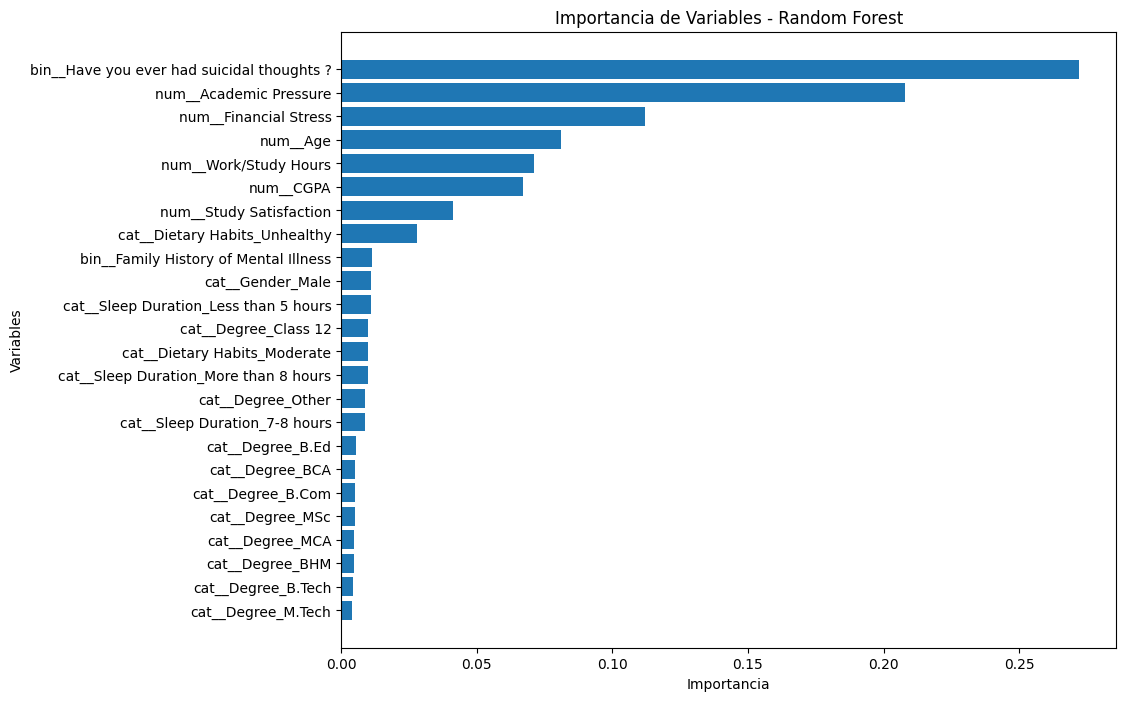

In [24]:
rf_model = model_rf.named_steps["model"] #Obtener el modelo interno del pipeline
importances = rf_model.feature_importances_ #Extraer importancias
feature_importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})
feature_importance_df = feature_importance_df.sort_values(by="Importancia", ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    feature_importance_df["Variable"],
    feature_importance_df["Importancia"]
)
ax.invert_yaxis()
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.savefig("../outputs/plots/feature_importance_rf.png", bbox_inches="tight")
plt.show()